In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import ModelConfig
from membraneReactorModel import MembraneReactorModel
from reaction import ReactionRates


In [2]:
cfg = ModelConfig()
model = MembraneReactorModel(cfg)
reaction = ReactionRates(cfg)

result = model.solve()

In [ ]:
c_g, c_b, c_p, c_m = model.fields()
r1, r2 = reaction.reaction_rates(c_b[:, None, :], cfg)
eta_r1, eta_r2, _, _ = model.effectiveness_profile()
P_pa_bulk, P_bar_bulk, _ = reaction.partial_pressures(c_g, cfg)
mears_r1, mears_r2 = model.mears_criterion()
wp_r1, wp_r2 = model.weisz_prater_criterion()

c_surf_CO2 = np.maximum(c_p[:, -1, 0].mean(), 1e-30)
k_app_r1   = r1[:, 0].mean() / c_surf_CO2

X_CO2 = (1.0 - c_g[:, 0]) / c_g[0, 0]
X_MeOH = (2.0 * c_g[:, 4]) / np.maximum(c_g[:, 2] + 2.0 * c_g[:, 4], 1e-30)

fmt = "{:.2f}".format

print(pd.Series({
    "success":                   result.success,
    "Newton iterations":         result.nit,
    "residual norm (inf)":       np.linalg.norm(result.fun, ord=np.inf),
    "residence time [s]":        cfg.tau,
    "Re_number [-]":             cfg.Reynolds,
    "Sc_number [-]":             cfg.Schmidt[0],
    "Bo_ax [-]":                 cfg.v_ret * cfg.length / cfg.particle_diffusivity[:3],
    "Pe_ax [-]":                 cfg.rho_gas * cfg.Cp_gas * cfg.v_ret * cfg.length / cfg.thermal_conductivity_ax, # THIS HAS YET TO BE IMPLEMENTED CORRECTLY
    "η analytisch R1 [-]":       eta_r1[0],
    "η analytisch R2 [-]":       eta_r2[0],
}, name="solver & diagnostics").to_string(float_format=fmt))

print(pd.Series(
    {
    "reactor length [m]":        cfg.length,
    "R_ret [m]":                 cfg.R_ret,
    "v_ret [m/s]":               cfg.v_ret,
    "n_z [-]":                   cfg.n_z,
    "n_r_ret [-]":               cfg.n_r_ret,
    "T [K]":                     cfg.T,
    "p [Pa]":                    cfg.p,
    "eps_s [-]":                 cfg.eps_s,
    "eps_p [-]":                 cfg.eps_p,
    "rho_bulk [kg/m³]":          cfg.rho_bulk,
    "m_cat [kg]":                cfg.m_cat,
    "external area [1/m]":       cfg.external_area,
    "volume per tube [m³]":      cfg.v_tube,
}, name="Reactor configuration").to_string(float_format = fmt))

print(pd.Series(
    {
    "partial pressure of H2":    P_pa_bulk[-1,1],
    "partial pressure of CO2":   P_pa_bulk[-1,0],
    "partial pressure of H2O":   P_pa_bulk[-1,3],
    "partial pressure of meOH":  P_pa_bulk[-1,2],
    "partial pressure of DMC":   P_pa_bulk[-1,4],
    "pressure drop":             cfg.ergun_pressure_gradient,
}, name="Partial pressures").to_string(float_format = fmt))

print(pd.Series(   
    {
    "H2  inlet":                          c_g[0,1],
    "CO2 inlet":                          c_g[0,0],
    "outlet CH3OH [mol/m³]":              c_g[-1, 2],
    "outlet DMC [mol/m³]":                c_g[-1, 4],
    "outlet H2O permeate [mol/m³]":       c_m[-1, 3],
    "Conversion R1":                      X_CO2[-1],
    "Conversion R2":                      X_MeOH[-1],
}, name="conversion and products"))

print(pd.Series(
    {
    "k_eff R1  [mol/s/bar²/kg]":          reaction.k_eff_r1(cfg, cfg.T),
    "k_eff R2  [g/cat/s]":                reaction.k_eff_r2(cfg, cfg.p, cfg.T),
    "r1 inlet  [mol/m³/s]":               r1[0,  0],
    "r1 outlet [mol/m³/s]":               r1[-1, 0],
    "r2 inlet  [mol/m³/s]":               r2[0,  0],
    "r2 outlet [mol/m³/s]":               r2[-1, 0],
}, name="reaction kinetics"))

success                                                            True
Newton iterations                                                    16
residual norm (inf)                                                0.00
residence time [s]                                               400.00
Re_number [-]                                                     65.66
Sc_number [-]                                                      0.76
Bo_ax [-]              [500000.0, 666666.6666666666, 666666.6666666666]
Pe_ax [-]                                                         13.13
η analytisch R1 [-]                                                1.00
η analytisch R2 [-]                                                1.08
reactor length [m]          20.00
R_ret [m]                    0.01
v_ret [m/s]                  0.05
n_z [-]                    100.00
n_r_ret [-]                 30.00
T [K]                      573.15
p [Pa]                 5000000.00
eps_s [-]                    0.40
eps_p [-

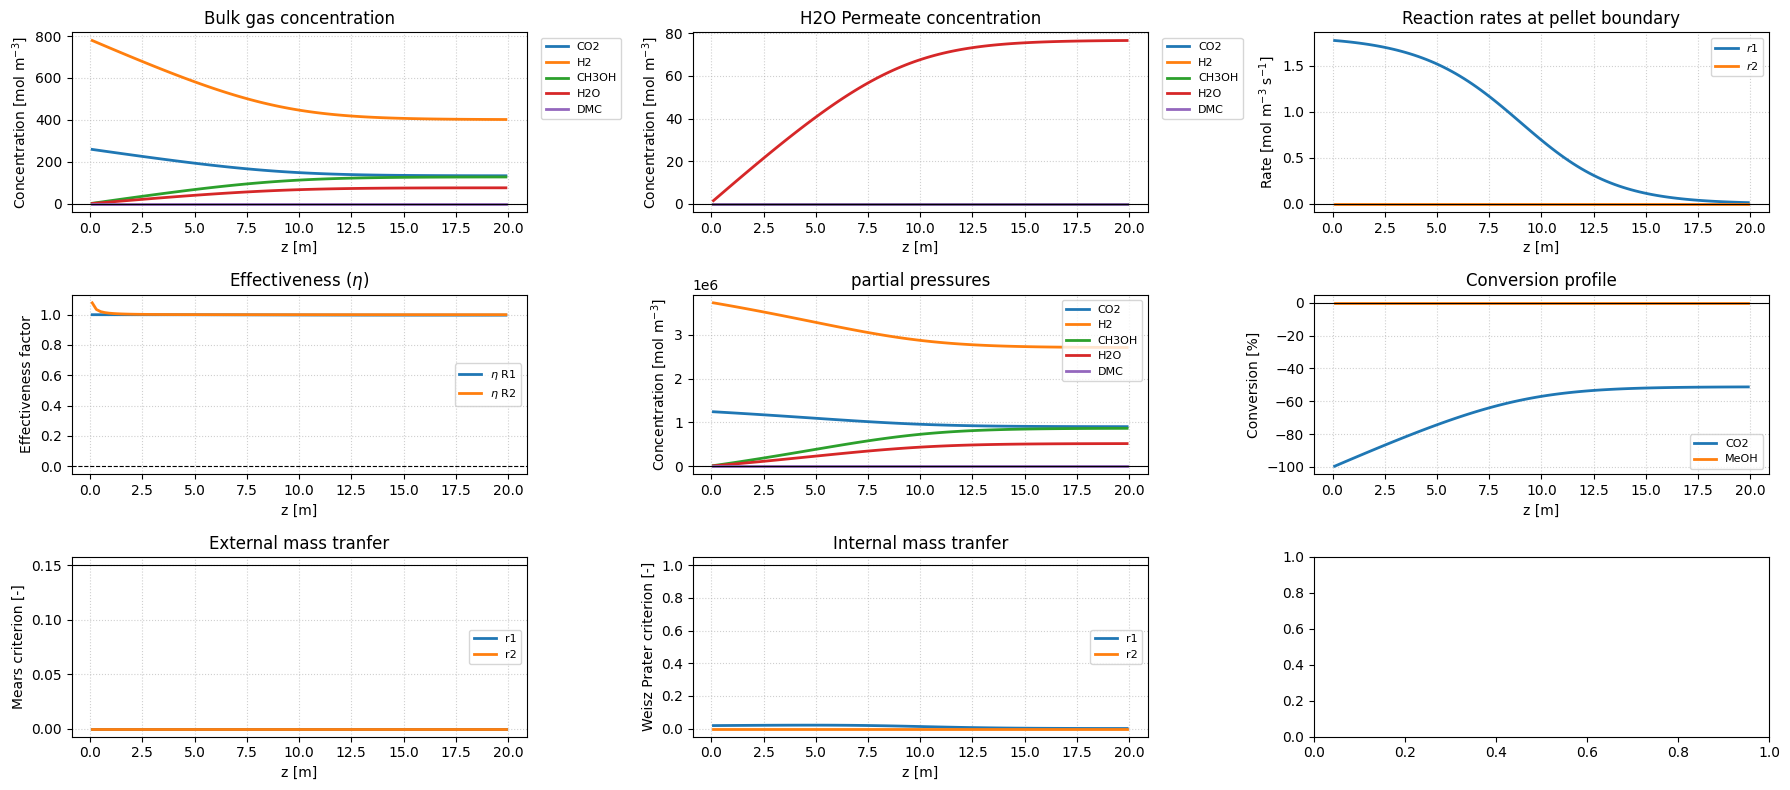

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 8), sharex=False)
axes = axes.flatten()
 
# axes[0]: Bulk Gas Concentration
for i, label in enumerate(model.species_labels):
    axes[0].plot(model.z_c, c_g[:, i], label=label, linewidth=2)
axes[0].axhline(0.0, color="k", linewidth=0.8)
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("Concentration [mol m$^{-3}$]")
axes[0].set_title("Bulk gas concentration")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[0].grid(True, linestyle=":", alpha=0.6)
 
# axes[1]: H2O Permeate Concentration
for i, label in enumerate(model.species_labels):
    axes[1].plot(model.z_c, c_m[:, i], label=label, linewidth=2)
axes[1].axhline(0.0, color="k", linewidth=0.8)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel(r"Concentration [mol m$^{-3}$]")
axes[1].set_title("H2O Permeate concentration")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[1].grid(True, linestyle=":", alpha=0.6)
 
# axes[2]: Reaction Rates
axes[2].plot(model.z_c, r1, label=r"$r1$", linewidth=2)
axes[2].plot(model.z_c, r2, label=r"$r2$", linewidth=2)
axes[2].axhline(0.0, color="k", lw=0.8)
axes[2].set_xlabel("z [m]")
axes[2].set_ylabel("Rate [mol m$^{-3}$ s$^{-1}$]")
axes[2].set_title("Reaction rates at pellet boundary")
axes[2].legend(loc="best", fontsize=8)
axes[2].grid(True, linestyle=":", alpha=0.6)
 
# axes[3]: Effectiveness Profile
axes[3].plot(model.z_c, eta_r1, label=r"$\eta$ R1", linewidth=2)
axes[3].plot(model.z_c, eta_r2, label=r"$\eta$ R2", linewidth=2)
axes[3].axhline(0.0, color="k", linewidth=0.8, linestyle="--")
axes[3].set_xlabel("z [m]")
axes[3].set_ylabel("Effectiveness factor")
axes[3].set_title(r"Effectiveness ($\eta$)")
axes[3].grid(True, linestyle=":", alpha=0.6)
axes[3].legend(loc="best", fontsize=8)

for i, label in enumerate(model.species_labels):
    axes[4].plot(model.z_c, P_pa_bulk[:, i], label=label, linewidth=2)
axes[4].axhline(0.0, color="k", linewidth=0.8)
axes[4].set_ylabel("Concentration [mol m$^{-3}$]")
axes[4].set_title("partial pressures")
axes[4].legend(fontsize=8)
axes[4].grid(True, linestyle=":", alpha=0.6)

axes[5].plot(model.z_c, X_CO2 * 100, label="CO2", linewidth=2)
axes[5].plot(model.z_c, X_MeOH * 100, label="MeOH", linewidth=2)
axes[5].axhline(0.0, color="k", linewidth=0.8)
axes[5].set_xlabel("z [m]")
axes[5].set_ylabel("Conversion [%]")
axes[5].set_title("Conversion profile")
axes[5].legend(fontsize=8)
axes[5].grid(True, linestyle=":", alpha=0.6)

axes[6].plot(model.z_c, mears_r1, label="r1", linewidth=2)
axes[6].plot(model.z_c, mears_r2, label="r2", linewidth=2)
axes[6].axhline(0.15, color="k", linewidth=0.8)
axes[6].set_xlabel("z [m]")
axes[6].set_ylabel("Mears criterion [-]")
axes[6].set_title("External mass tranfer")
axes[6].legend(fontsize=8)
axes[6].grid(True, linestyle=":", alpha=0.6)

axes[7].plot(model.z_c, wp_r1, label="r1", linewidth=2)
axes[7].plot(model.z_c, wp_r2, label="r2", linewidth=2)
axes[7].axhline(1, color="k", linewidth=0.8)
axes[7].set_xlabel("z [m]")
axes[7].set_ylabel("Weisz Prater criterion [-]")
axes[7].set_title("Internal mass tranfer")
axes[7].legend(fontsize=8)
axes[7].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()